**Packages needed to be imported**

In [14]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

**Loading the data**

In [3]:
(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


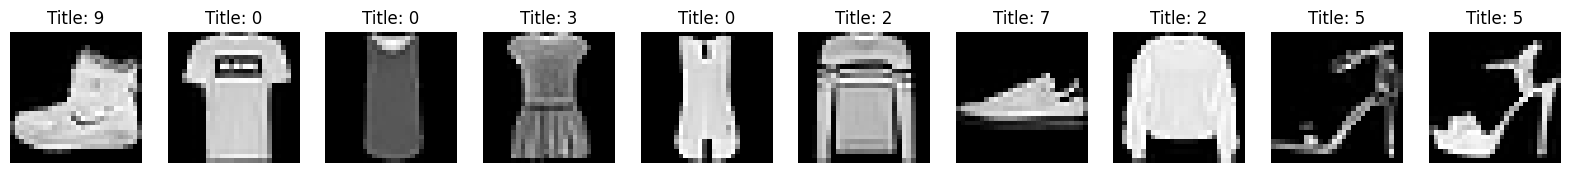

In [5]:
n=10
plt.figure(figsize=(20,5))
for i in range(n):
  plt.subplot(1,n,i+1)
  plt.imshow(train_images[i],cmap='gray')
  plt.title(f'Title: {train_labels[i]}')
  plt.axis('off')

In [ ]:
'''
0 → T-shirt/top
1 → Trouser
2 → Pullover
3 → Dress
4 → Coat
5 → Sandal
6 → Shirt
7 → Sneaker
8 → Bag
9 → Ankle boot
'''

**Normalization**


In [6]:
train_images=train_images.astype('float32')/255
test_images=test_images.astype('float32')/255

**Reshaping**

In [11]:
train_images=train_images.reshape(train_images.shape[0],28*28)
test_images=test_images.reshape(test_images.shape[0],28*28)

In [13]:
train_images.shape

(60000, 784)

**One-hot encoding**

In [15]:
train_labels=tf.keras.utils.to_categorical(train_labels)
test_labels=tf.keras.utils.to_categorical(test_labels)

**Model Building**

In [21]:
e_dim=64
input_img=Input(shape=(784,))
encoded=Dense(e_dim,activation='relu')(input_img)
decoded=Dense(10,activation='softmax')(encoded)
autoencoded=Model(input_img,decoded)

In [26]:
autoencoded.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])
autoencoded.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history=autoencoded.fit(train_images,train_labels,
                        epochs=50,
                        validation_data=(test_images,test_labels),
                        shuffle=True,
                        batch_size=256)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9228 - loss: 0.2184 - val_accuracy: 0.8824 - val_loss: 0.4067
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9305 - loss: 0.1914 - val_accuracy: 0.8830 - val_loss: 0.3934
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9308 - loss: 0.1942 - val_accuracy: 0.8812 - val_loss: 0.3963
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9303 - loss: 0.1876 - val_accuracy: 0.8821 - val_loss: 0.3874
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9329 - loss: 0.1879 - val_accuracy: 0.8766 - val_loss: 0.3973
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9321 - loss: 0.1857 - val_accuracy: 0.8785 - val_loss: 0.3863
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9350 - loss: 0.1769 - val_accuracy: 0.8832 - val_loss: 0.3790
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9369 - loss: 0.1740 - val_accuracy: 0.

In [28]:
loss,accuracy=autoencoded.evaluate(test_images,test_labels)
print(f'Loss {loss}')
print(f'Accuracy {accuracy*100}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8811 - loss: 0.4417
Loss 0.43903782963752747
Accuracy 88.08000087738037


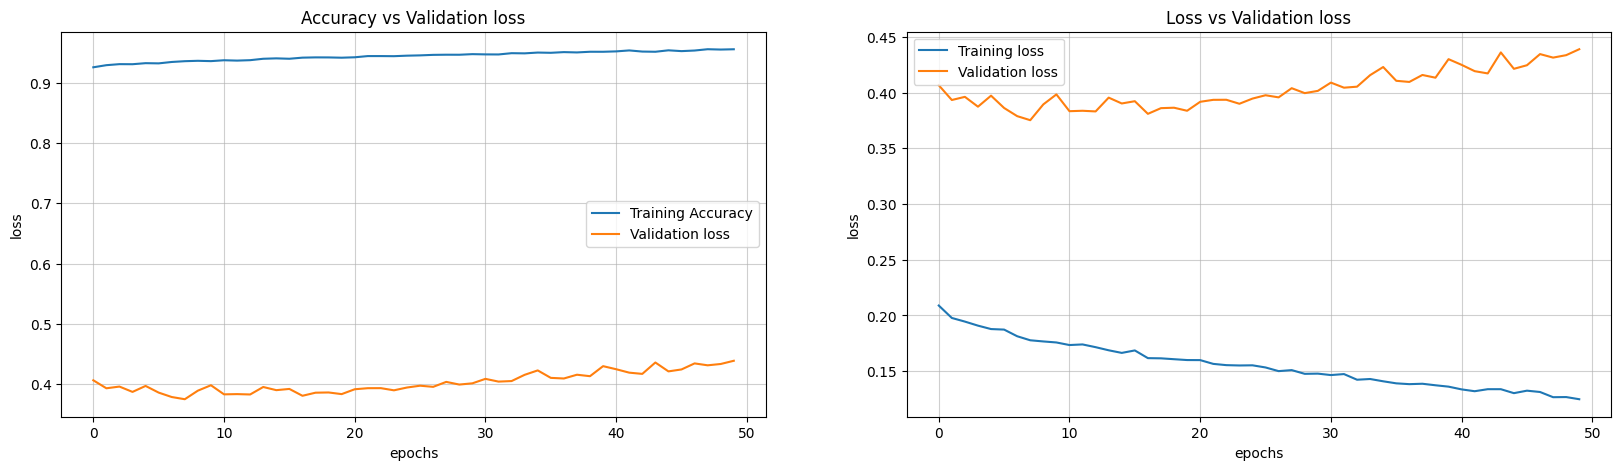

In [34]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.title('Accuracy vs Validation loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(alpha=0.6)

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.title('Loss vs Validation loss')
plt.xlabel('epochs')
plt.legend()
plt.ylabel('loss')
plt.grid(alpha=0.6)